<a href="https://colab.research.google.com/github/Cumikkk/segmentasi-citra/blob/main/segmentasi_citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving tomat.webp to tomat (10).webp
Ukuran gambar: (395, 640, 3)


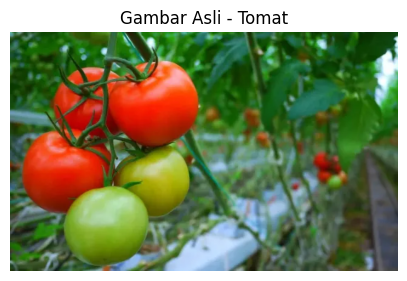

In [78]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, filters, feature, morphology, measure, segmentation
from skimage.segmentation import active_contour
from skimage.filters import gaussian
from skimage.draw import polygon
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage
import cv2
from google.colab import files
from PIL import Image
import io as byte_io

# upload gambar dari komputer
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img_rgb = np.array(Image.open(byte_io.BytesIO(uploaded[filename])))

# pastikan format RGB (bukan RGBA)
if img_rgb.shape[-1] == 4:
    img_rgb = img_rgb[:, :, :3]

img_gray = color.rgb2gray(img_rgb)

print("Ukuran gambar:", img_rgb.shape)
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title("Gambar Asli - Tomat")
plt.axis('off')
plt.show()

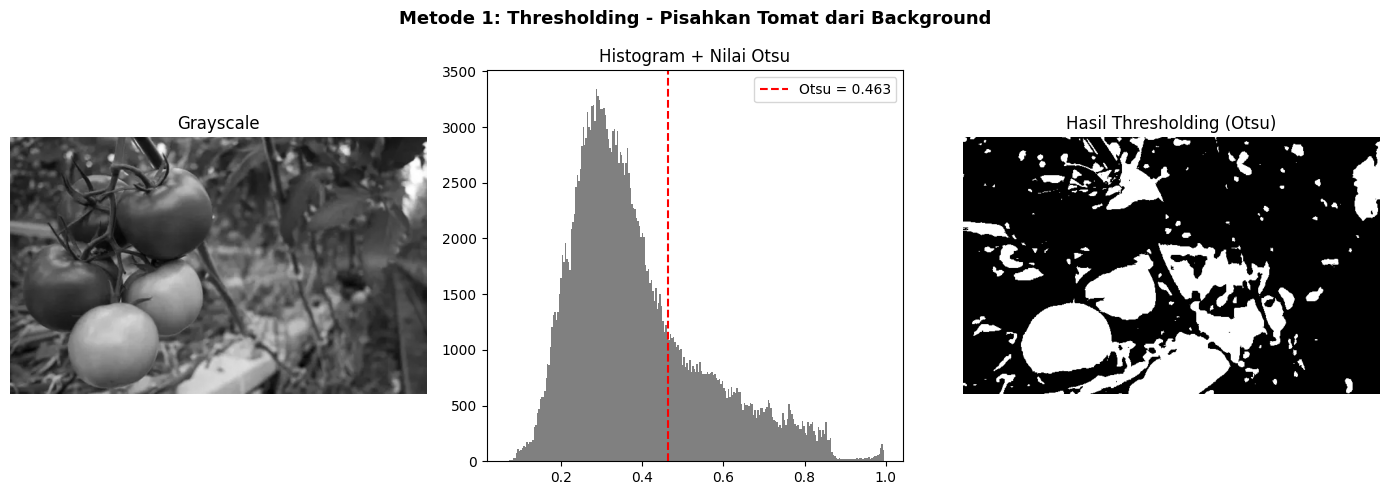

Nilai threshold Otsu: 0.4628


In [79]:
# metode 1: thresholding
# tujuan: pisahkan area tomat (terang) dari background gelap
thresh_val = filters.threshold_otsu(img_gray)
img_thresh = img_gray > thresh_val

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Grayscale")
axes[0].axis('off')

axes[1].hist(img_gray.ravel(), bins=256, color='gray')
axes[1].axvline(thresh_val, color='red', linestyle='--', label=f'Otsu = {thresh_val:.3f}')
axes[1].set_title("Histogram + Nilai Otsu")
axes[1].legend()

axes[2].imshow(img_thresh, cmap='gray')
axes[2].set_title("Hasil Thresholding (Otsu)")
axes[2].axis('off')

plt.suptitle("Metode 1: Thresholding - Pisahkan Tomat dari Background", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Nilai threshold Otsu: {thresh_val:.4f}")

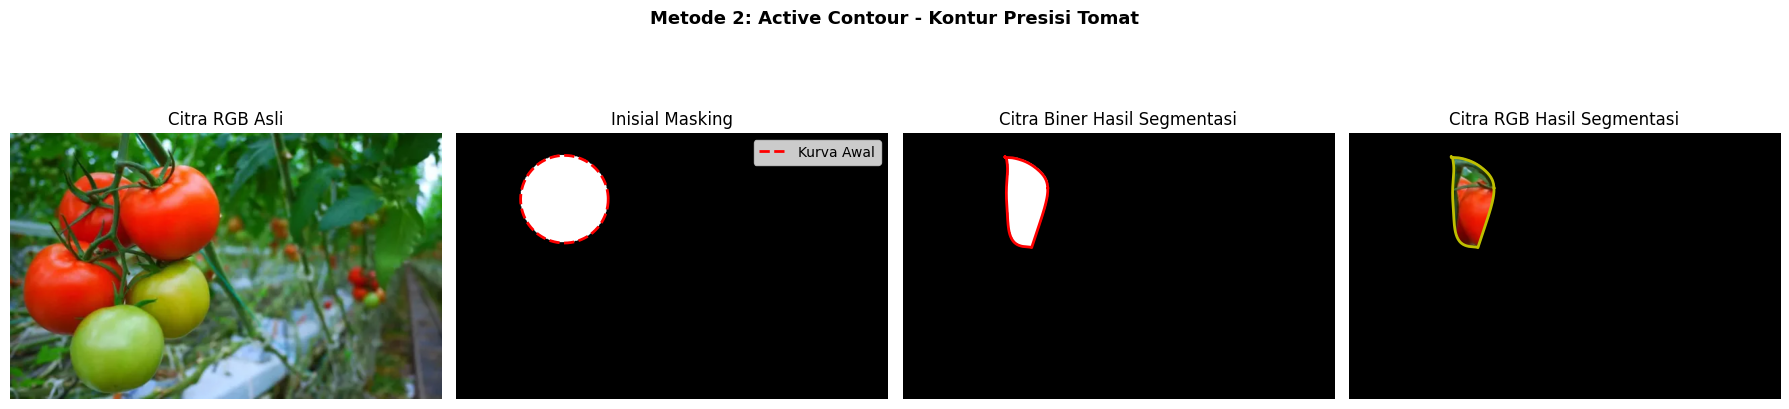

In [80]:
# metode 2: active contour
# tujuan: deteksi batas/kontur presisi satu tomat
img_smooth = gaussian(img_gray, sigma=3)

# kurva awal melingkari tomat merah besar di kiri atas
s = np.linspace(0, 2 * np.pi, 400)
cx = img_rgb.shape[1] // 4
cy = img_rgb.shape[0] // 4
r = min(img_rgb.shape[:2]) // 6

init_snake = np.array([cy + r * np.sin(s), cx + r * np.cos(s)]).T

# jalankan active contour
snake = active_contour(
    img_smooth,
    init_snake,
    alpha=0.015,
    beta=10,
    gamma=0.001,
    max_num_iter=250
)

# buat mask dari hasil snake
mask = np.zeros(img_gray.shape, dtype=bool)
rr, cc = polygon(snake[:, 0], snake[:, 1], img_gray.shape)
mask[rr, cc] = True

# hasil biner
img_biner = mask.astype(np.uint8) * 255

# hasil rgb
img_rgb_result = img_rgb.copy()
img_rgb_result[~mask] = 0

# inisial masking
mask_init = np.zeros(img_gray.shape, dtype=np.uint8)
rr_init, cc_init = polygon(init_snake[:, 0], init_snake[:, 1], img_gray.shape)
mask_init[rr_init, cc_init] = 255

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Citra RGB Asli")
axes[0].axis('off')

axes[1].imshow(mask_init, cmap='gray')
axes[1].plot(init_snake[:, 1], init_snake[:, 0], 'r--', lw=2, label='Kurva Awal')
axes[1].set_title("Inisial Masking")
axes[1].legend()
axes[1].axis('off')

axes[2].imshow(img_biner, cmap='gray')
axes[2].plot(snake[:, 1], snake[:, 0], 'r-', lw=2)
axes[2].set_title("Citra Biner Hasil Segmentasi")
axes[2].axis('off')

axes[3].imshow(img_rgb_result)
axes[3].plot(snake[:, 1], snake[:, 0], 'y-', lw=2)
axes[3].set_title("Citra RGB Hasil Segmentasi")
axes[3].axis('off')

plt.suptitle("Metode 2: Active Contour - Kontur Presisi Tomat", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

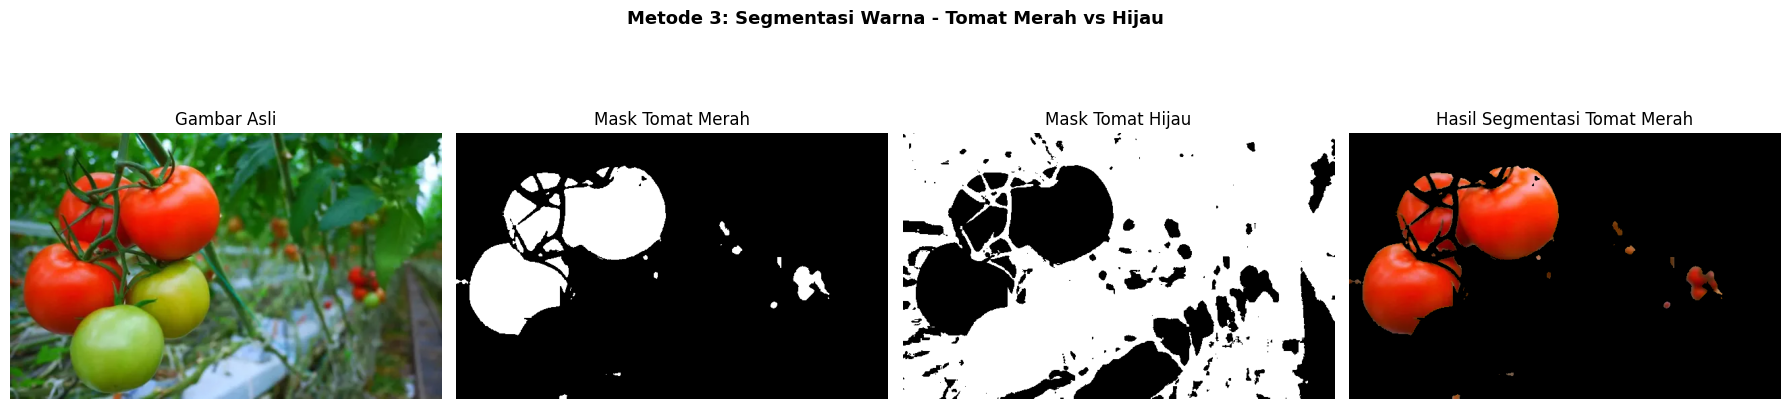

In [81]:
# metode 3: segmentasi warna
# tujuan: bedakan tomat merah, tomat hijau, dan daun
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# mask tomat merah (merah ada di dua range di HSV)
lower_red1 = np.array([0, 80, 80], dtype=np.uint8)
upper_red1 = np.array([15, 255, 255], dtype=np.uint8)
lower_red2 = np.array([155, 80, 80], dtype=np.uint8)
upper_red2 = np.array([179, 255, 255], dtype=np.uint8)
mask_red1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask_red2 = cv2.inRange(img_hsv, lower_red2, upper_red2)
mask_merah = cv2.bitwise_or(mask_red1, mask_red2)

# mask tomat hijau (hijau kekuningan)
lower_hijau_tomat = np.array([25, 40, 40], dtype=np.uint8)
upper_hijau_tomat = np.array([85, 255, 255], dtype=np.uint8)
mask_hijau_tomat = cv2.inRange(img_hsv, lower_hijau_tomat, upper_hijau_tomat)

# apply mask
result_merah = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_merah)
result_hijau = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_hijau_tomat)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Gambar Asli")
axes[0].axis('off')

axes[1].imshow(mask_merah, cmap='gray')
axes[1].set_title("Mask Tomat Merah")
axes[1].axis('off')

axes[2].imshow(mask_hijau_tomat, cmap='gray')
axes[2].set_title("Mask Tomat Hijau")
axes[2].axis('off')

axes[3].imshow(result_merah)
axes[3].set_title("Hasil Segmentasi Tomat Merah")
axes[3].axis('off')

plt.suptitle("Metode 3: Segmentasi Warna - Tomat Merah vs Hijau", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

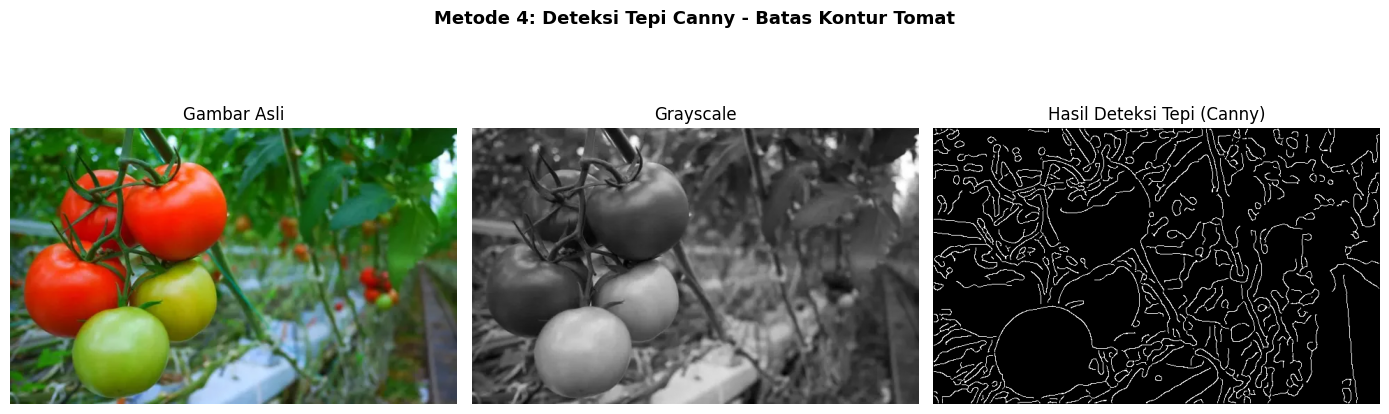

In [82]:
# metode 4: deteksi tepi canny
# tujuan: temukan batas kontur semua tomat sekaligus
img_blur = gaussian(img_gray, sigma=2)

edges_canny = feature.canny(img_blur, sigma=1.0, low_threshold=0.05, high_threshold=0.15)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Gambar Asli")
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title("Grayscale")
axes[1].axis('off')

axes[2].imshow(edges_canny, cmap='gray')
axes[2].set_title("Hasil Deteksi Tepi (Canny)")
axes[2].axis('off')

plt.suptitle("Metode 4: Deteksi Tepi Canny - Batas Kontur Tomat", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

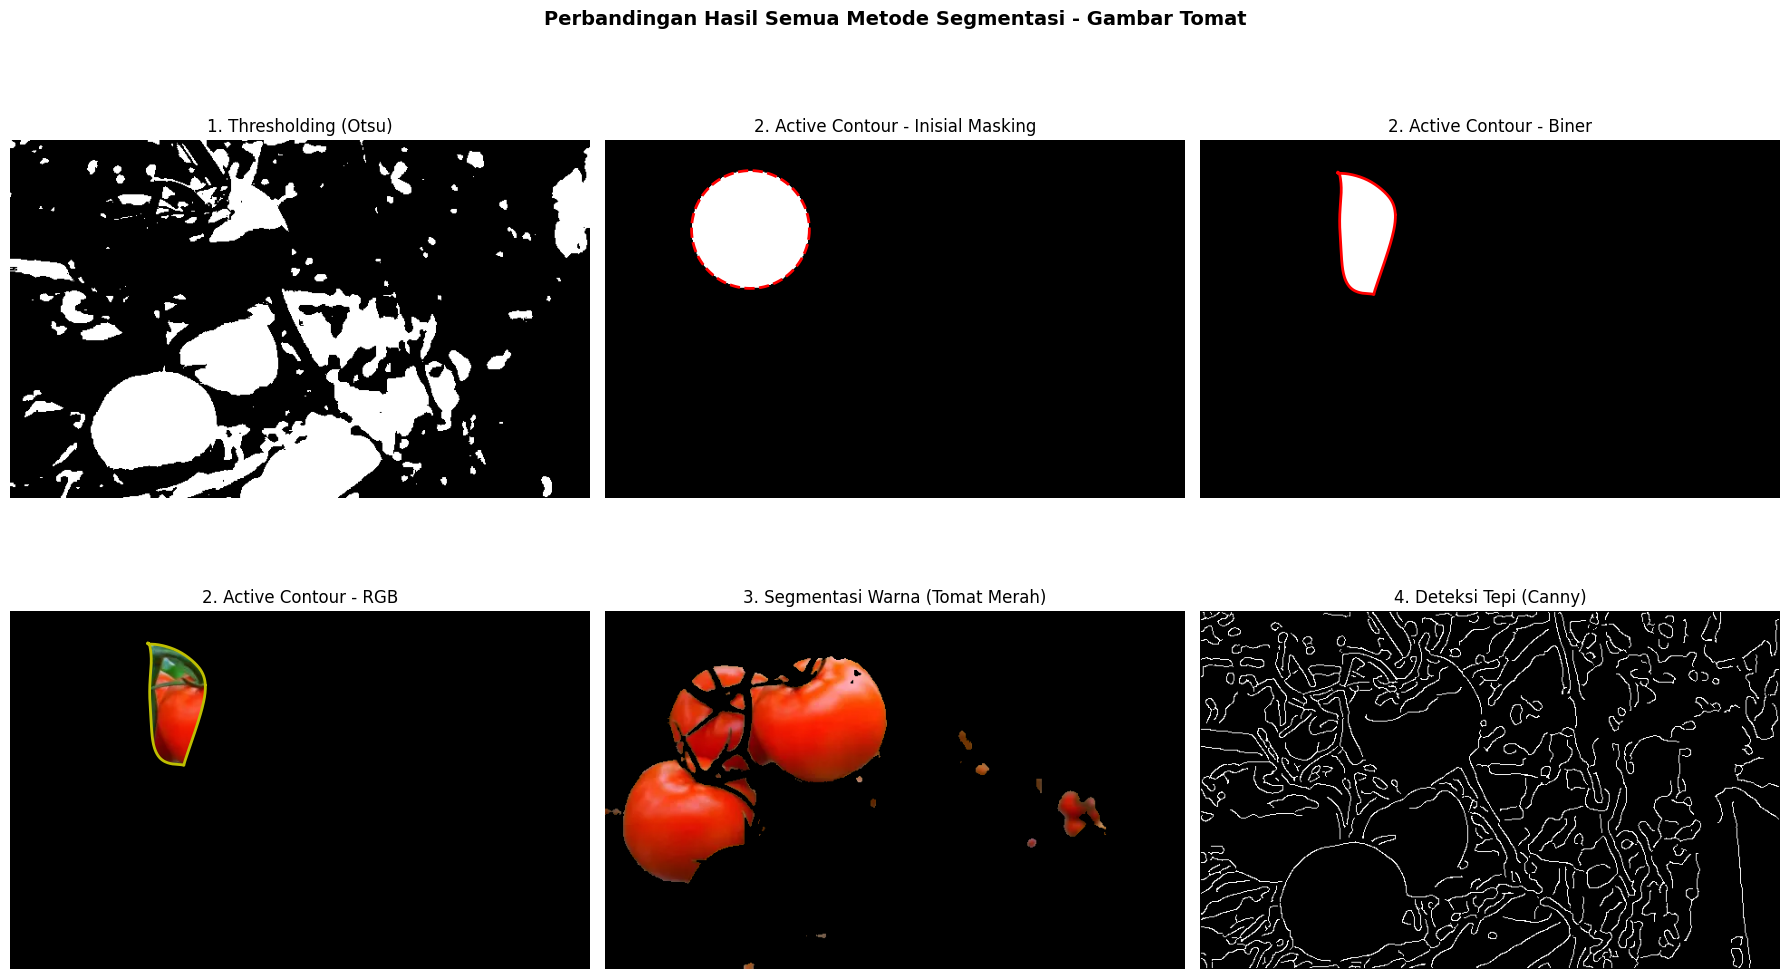

In [83]:
# tampilan hasil semua metode sekaligus
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# baris 1
axes[0, 0].imshow(img_thresh, cmap='gray')
axes[0, 0].set_title("1. Thresholding (Otsu)", fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_init, cmap='gray')
axes[0, 1].plot(init_snake[:, 1], init_snake[:, 0], 'r--', lw=2)
axes[0, 1].set_title("2. Active Contour - Inisial Masking", fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(img_biner, cmap='gray')
axes[0, 2].plot(snake[:, 1], snake[:, 0], 'r-', lw=2)
axes[0, 2].set_title("2. Active Contour - Biner", fontsize=12)
axes[0, 2].axis('off')

# baris 2
axes[1, 0].imshow(img_rgb_result)
axes[1, 0].plot(snake[:, 1], snake[:, 0], 'y-', lw=2)
axes[1, 0].set_title("2. Active Contour - RGB", fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(result_merah)
axes[1, 1].set_title("3. Segmentasi Warna (Tomat Merah)", fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(edges_canny, cmap='gray')
axes[1, 2].set_title("4. Deteksi Tepi (Canny)", fontsize=12)
axes[1, 2].axis('off')

plt.suptitle("Perbandingan Hasil Semua Metode Segmentasi - Gambar Tomat", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

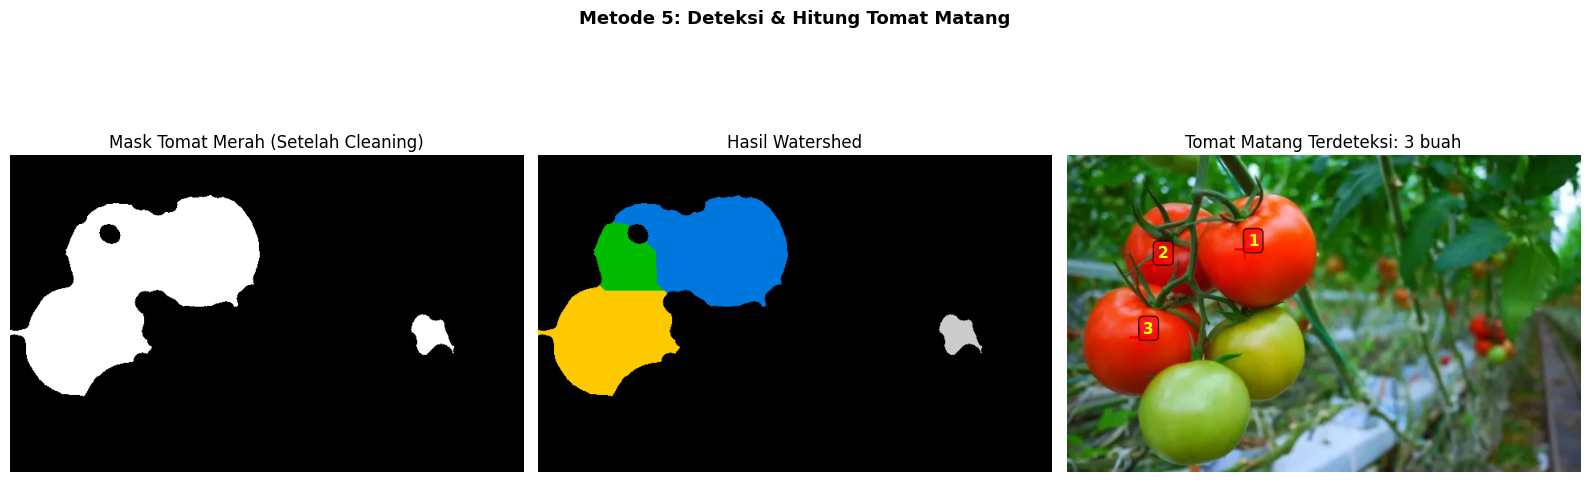

In [84]:
# metode 5: deteksi dan hitung tomat matang (merah)
# tujuan: hitung jumlah tomat yang sudah matang

# gunakan mask merah dari cell 4
# morphological closing untuk tutup lubang
mask_merah_clean = morphology.closing(mask_merah, morphology.disk(10))
mask_merah_clean = morphology.remove_small_objects(mask_merah_clean.astype(bool), min_size=1000)

# distance transform + watershed
distance = ndimage.distance_transform_edt(mask_merah_clean)
coords = peak_local_max(distance, min_distance=30, labels=mask_merah_clean)
mask_peaks = np.zeros(distance.shape, dtype=bool)
mask_peaks[tuple(coords.T)] = True
markers, _ = ndimage.label(mask_peaks)
labels_watershed = watershed(-distance, markers, mask=mask_merah_clean)

# hitung dan anotasi
properties = measure.regionprops(labels_watershed)
min_area = 3000
tomat_matang = [prop for prop in properties if prop.area >= min_area]
jumlah_matang = len(tomat_matang)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(mask_merah_clean, cmap='gray')
axes[0].set_title("Mask Tomat Merah (Setelah Cleaning)")
axes[0].axis('off')

axes[1].imshow(labels_watershed, cmap='nipy_spectral')
axes[1].set_title("Hasil Watershed")
axes[1].axis('off')

axes[2].imshow(img_rgb)
for i, prop in enumerate(tomat_matang):
    y, x = prop.centroid
    axes[2].plot(x, y, 'r+', markersize=14, markeredgewidth=2)
    axes[2].text(x + 5, y - 5, str(i + 1), color='yellow',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7))
axes[2].set_title(f"Tomat Matang Terdeteksi: {jumlah_matang} buah")
axes[2].axis('off')

plt.suptitle("Metode 5: Deteksi & Hitung Tomat Matang", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()